# 📈 Sales Demand Forecasting — Superstore Dataset
**Author:** Muhammad Laeeq Ur Rehman | github.com/data00077  
**Dataset:** Superstore Sales (9,800 rows)  
**Goal:** Forecast future sales demand using Time Series analysis (Prophet)

### Dataset Columns:
- `Order Date` — Date of order
- `Sales` — Sales amount (USD)
- `Category` — Furniture / Office Supplies / Technology
- `Region` — West / East / Central / South
- `Segment` — Consumer / Corporate / Home Office

## 📦 STEP 1 — Install & Import Libraries

In [1]:
# Install Prophet (run once)
# !pip install prophet pandas matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print('✅ Libraries imported!')

✅ Libraries imported!


## 📂 STEP 2 — Load Dataset

In [2]:
# Load dataset
df = pd.read_csv('train.csv')

print(f'📊 Shape: {df.shape}')
print(f'📋 Columns: {list(df.columns)}')
print()
df.head()

📊 Shape: (9800, 18)
📋 Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']



,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## 🔍 STEP 3 — Data Cleaning & Preparation

In [3]:
# Parse dates — format is DD/MM/YYYY
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

# Check missing values
print('Missing Values:')
print(df.isnull().sum())
print()

# Date range
print(f'Date Range: {df["Order Date"].min()} → {df["Order Date"].max()}')
print(f'Total Sales: ${df["Sales"].sum():,.2f}')
print(f'Categories: {df["Category"].unique()}')
print(f'Regions: {df["Region"].unique()}')

Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Date Range: 2015-01-03 00:00:00 → 2018-12-30 00:00:00
Total Sales: $2,261,536.78
Categories: ['Furniture' 'Office Supplies' 'Technology']
Regions: ['South' 'West' 'Central' 'East']


## 📊 STEP 4 — Exploratory Data Analysis

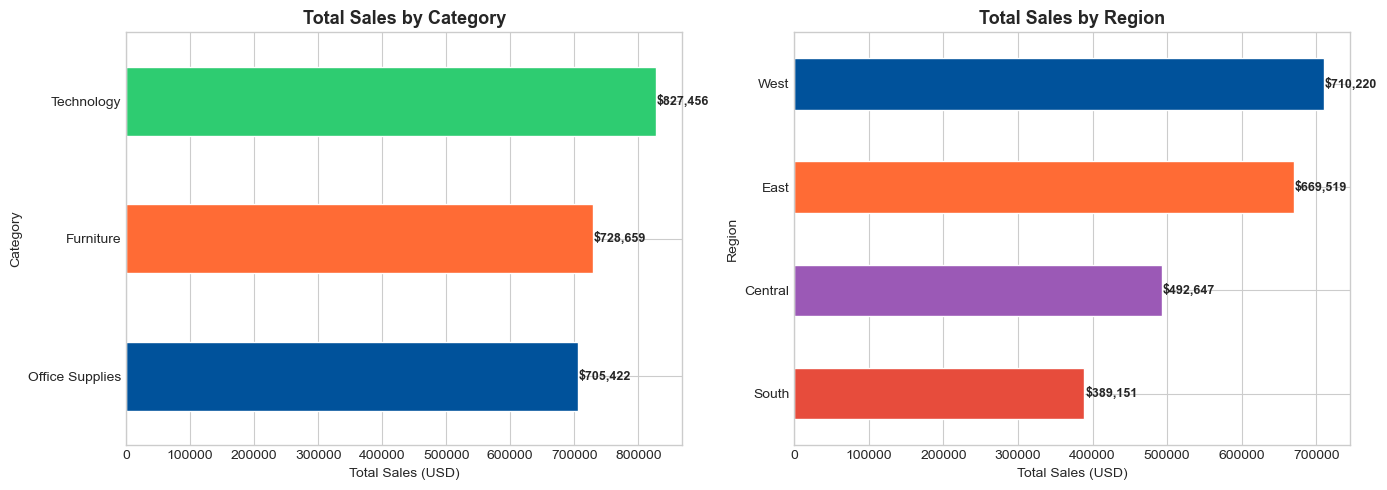

✅ Saved!


In [4]:
# ── PLOT 1: Sales by Category & Region ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Category
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=True)
colors = ['#00529B', '#FF6B35', '#2ECC71']
cat_sales.plot(kind='barh', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Total Sales by Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Sales (USD)')
for i, v in enumerate(cat_sales.values):
    axes[0].text(v + 1000, i, f'${v:,.0f}', va='center', fontweight='bold', fontsize=9)

# Region
reg_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=True)
reg_colors = ['#E74C3C', '#9B59B6', '#FF6B35', '#00529B']
reg_sales.plot(kind='barh', ax=axes[1], color=reg_colors, edgecolor='white')
axes[1].set_title('Total Sales by Region', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Sales (USD)')
for i, v in enumerate(reg_sales.values):
    axes[1].text(v + 1000, i, f'${v:,.0f}', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('plot1_sales_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved!')

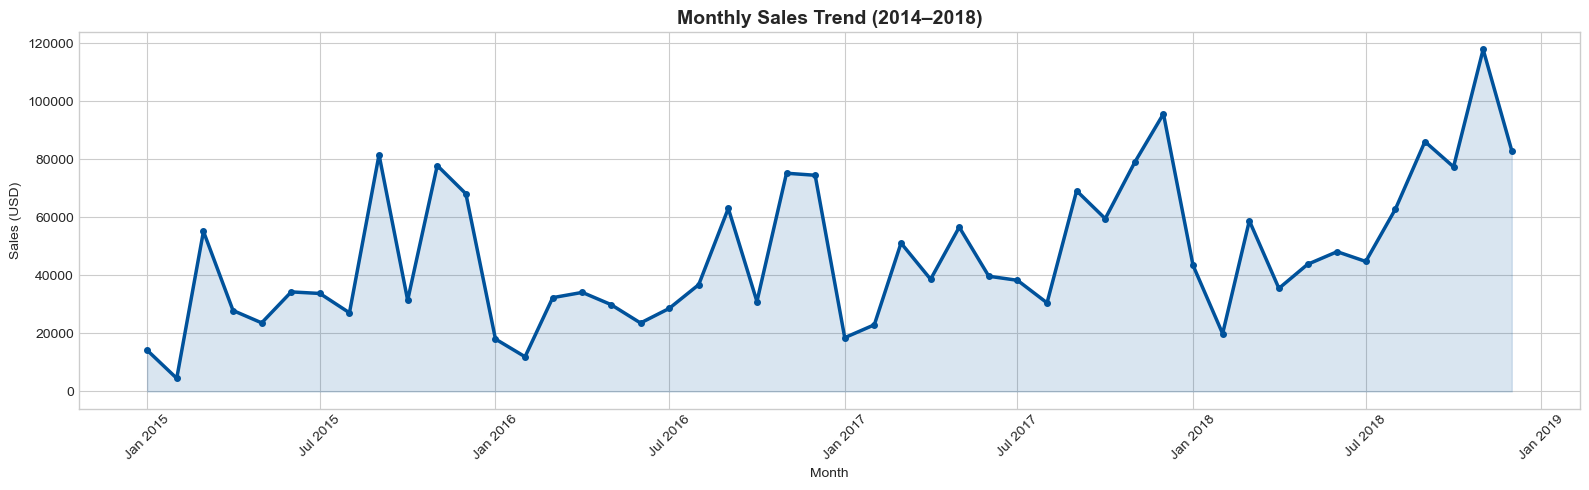

✅ Saved!


In [5]:
# ── PLOT 2: Monthly Sales Trend ──
monthly = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(monthly.index, monthly.values, color='#00529B', linewidth=2.5, marker='o', markersize=4)
ax.fill_between(monthly.index, monthly.values, alpha=0.15, color='#00529B')
ax.set_title('Monthly Sales Trend (2014–2018)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Sales (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot2_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved!')

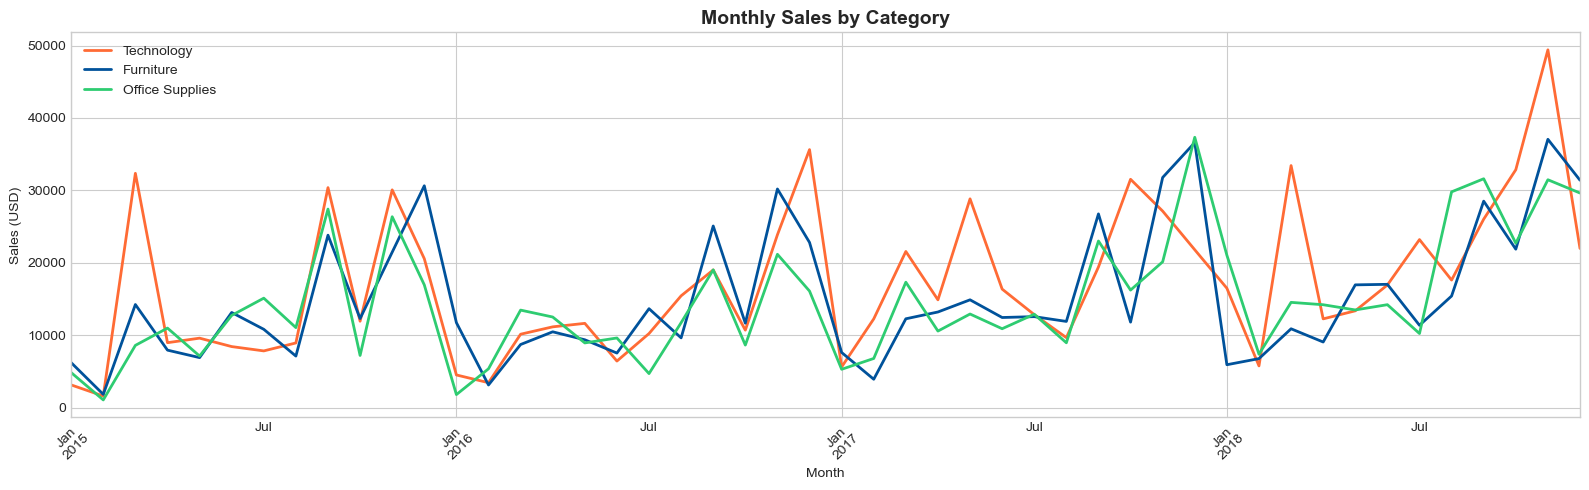

✅ Saved!


In [6]:
# ── PLOT 3: Sales by Category Over Time ──
cat_monthly = df.groupby([df['Order Date'].dt.to_period('M'), 'Category'])['Sales'].sum().unstack()
cat_monthly.index = cat_monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(16, 5))
cat_monthly['Technology'].plot(ax=ax, color='#FF6B35', linewidth=2, label='Technology')
cat_monthly['Furniture'].plot(ax=ax, color='#00529B', linewidth=2, label='Furniture')
cat_monthly['Office Supplies'].plot(ax=ax, color='#2ECC71', linewidth=2, label='Office Supplies')

ax.set_title('Monthly Sales by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Sales (USD)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot3_category_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved!')

## 🤖 STEP 5 — Prophet Forecasting Model

In [6]:
# Prepare data for Prophet
# Prophet needs exactly 2 columns: 'ds' (date) and 'y' (value)
prophet_df = df.groupby('Order Date')['Sales'].sum().reset_index()
prophet_df.columns = ['ds', 'y']
prophet_df = prophet_df.sort_values('ds')

print(f'✅ Prophet data ready!')
print(f'Total rows: {len(prophet_df)}')
print(prophet_df.head())

✅ Prophet data ready!
Total rows: 1230
          ds         y
0 2015-01-03    16.448
1 2015-01-04   288.060
2 2015-01-05    19.536
3 2015-01-06  4407.100
4 2015-01-07    87.158


In [7]:
# Train Prophet Model
print('🚀 Training Prophet model...')

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)

model.fit(prophet_df)
print('✅ Model trained!')

🚀 Training Prophet model...


20:30:55 - cmdstanpy - INFO - Chain [1] start processing
20:30:56 - cmdstanpy - INFO - Chain [1] done processing


✅ Model trained!


In [8]:
# Forecast next 90 days
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

print('📅 Forecast for next 90 days:')
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

📅 Forecast for next 90 days:
             ds         yhat   yhat_lower   yhat_upper
1310 2019-03-21  1877.828700  -935.336366  4582.663027
1311 2019-03-22  2834.366598    98.852064  5543.223599
1312 2019-03-23  3320.023818   560.963616  6104.972212
1313 2019-03-24  2911.713033   122.487924  5606.438352
1314 2019-03-25  2736.076633   165.748664  5511.784440
1315 2019-03-26  3066.295441   271.972100  5757.095280
1316 2019-03-27  2237.124836  -387.831976  5004.549094
1317 2019-03-28  1430.712781 -1444.344069  4139.396170
1318 2019-03-29  2358.599127  -260.302705  5017.923771
1319 2019-03-30  2824.405171  -126.285053  5544.026796


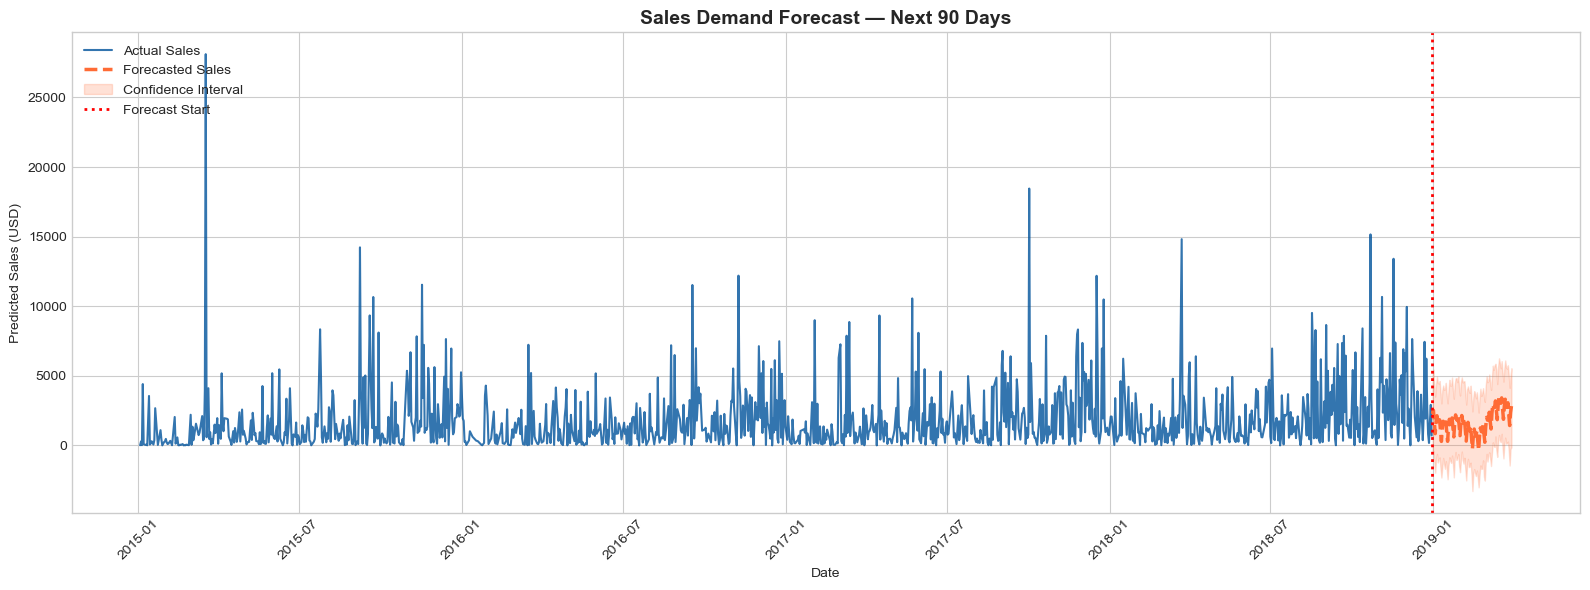

✅ Saved!


In [9]:
# ── PLOT 4: Forecast Chart ──
fig, ax = plt.subplots(figsize=(16, 6))

# Actual data
ax.plot(prophet_df['ds'], prophet_df['y'],
        color='#00529B', linewidth=1.5, label='Actual Sales', alpha=0.8)

# Forecast
forecast_only = forecast[forecast['ds'] > prophet_df['ds'].max()]
ax.plot(forecast_only['ds'], forecast_only['yhat'],
        color='#FF6B35', linewidth=2.5, linestyle='--', label='Forecasted Sales')

# Confidence interval
ax.fill_between(forecast_only['ds'],
                forecast_only['yhat_lower'],
                forecast_only['yhat_upper'],
                alpha=0.2, color='#FF6B35', label='Confidence Interval')

# Divider line
ax.axvline(x=prophet_df['ds'].max(), color='red',
           linestyle=':', linewidth=2, label='Forecast Start')

ax.set_title('Sales Demand Forecast — Next 90 Days', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Predicted Sales (USD)')
ax.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot4_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved!')

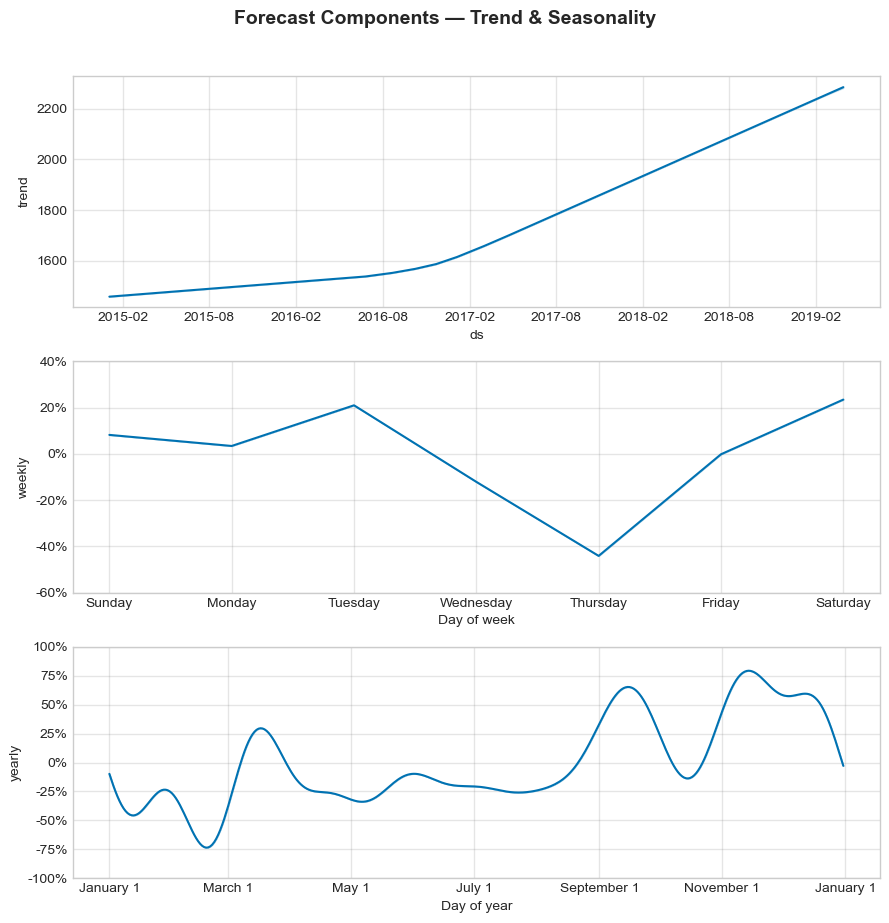

✅ Saved!


In [10]:
# ── PLOT 5: Forecast Components ──
fig = model.plot_components(forecast)
plt.suptitle('Forecast Components — Trend & Seasonality',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot5_components.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved!')

## 💡 STEP 6 — Business Insights

In [11]:
print('=' * 55)
print('📊 KEY BUSINESS INSIGHTS — DEMAND FORECASTING')
print('=' * 55)

# Overall stats
total_sales = df['Sales'].sum()
avg_monthly = monthly.mean()
best_month = monthly.idxmax().strftime('%B %Y')
best_month_sales = monthly.max()

print(f'\n💰 Total Sales (2014-2018):  ${total_sales:,.2f}')
print(f'📅 Avg Monthly Sales:         ${avg_monthly:,.2f}')
print(f'🏆 Best Month:                {best_month} (${best_month_sales:,.2f})')

# Category insights
print(f'\n📦 Category Performance:')
for cat, sales in cat_sales.sort_values(ascending=False).items():
    pct = sales/total_sales*100
    print(f'   {cat:20s}: ${sales:>10,.2f} ({pct:.1f}%)')

# Region insights
print(f'\n🌍 Regional Performance:')
for reg, sales in reg_sales.sort_values(ascending=False).items():
    pct = sales/total_sales*100
    print(f'   {reg:10s}: ${sales:>10,.2f} ({pct:.1f}%)')

# Forecast summary
next_30 = forecast_only.head(30)['yhat'].sum()
next_90 = forecast_only['yhat'].sum()
print(f'\n🔮 Forecast:')
print(f'   Next 30 days predicted sales: ${next_30:,.2f}')
print(f'   Next 90 days predicted sales: ${next_90:,.2f}')
print('=' * 55)

📊 KEY BUSINESS INSIGHTS — DEMAND FORECASTING

💰 Total Sales (2014-2018):  $2,261,536.78
📅 Avg Monthly Sales:         $47,115.35
🏆 Best Month:                November 2018 ($117,938.15)

📦 Category Performance:
   Technology          : $827,455.87 (36.6%)
   Furniture           : $728,658.58 (32.2%)
   Office Supplies     : $705,422.33 (31.2%)

🌍 Regional Performance:
   West      : $710,219.68 (31.4%)
   East      : $669,518.73 (29.6%)
   Central   : $492,646.91 (21.8%)
   South     : $389,151.46 (17.2%)

🔮 Forecast:
   Next 30 days predicted sales: $46,006.02
   Next 90 days predicted sales: $151,126.01


## ✅ Summary

This project demonstrates:
1. **Data Cleaning** — Date parsing, null handling on 9,800 rows
2. **EDA** — Sales by category, region, and monthly trends
3. **Time Series Forecasting** — Facebook Prophet model
4. **90-day Forecast** — With confidence intervals
5. **Seasonality Analysis** — Yearly & weekly patterns
6. **Business Insights** — Actionable recommendations

**Relevance to Telenor:** This forecasting approach is directly used in telecom for predicting network load, customer demand, and revenue planning — key functions at Telenor Pakistan.